# Stage 2: Meta-Learning Evaluation for Logistics

This notebook evaluates four adaptation strategies for the **Logistics** department in Stage 2 of the thesis pipeline:

1. **Fine-Tuning Baseline**
2. **FOMAML**
3. **MAML**
4. **ANIL**

The notebook assumes that:

- Stage 1 already produced a pretrained `TabularMLP`
- the Stage 1 preprocessing pipeline was exported
- Stage 2 uses the **Logistics** department as the target meta-test department
- support/query splits are created with `make_logistics_meta_test_split`

A key rule throughout this notebook is that raw feature frames may contain mixed dtypes, including categorical strings. Therefore, we **must always pass pandas feature frames through the Stage 1 preprocessor first** using `preprocessor.transform(...)` before creating PyTorch tensors.


In [4]:
from __future__ import annotations

import copy
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

sys.path.append("../src")

from master_thesis.stage2 import (
    load_stage2_config,
    resolve_stage2_paths,
    load_stage1_preprocessor,
    get_feature_cols,
    build_stage2_model_from_config,
    load_stage1_model_weights,
)

from master_thesis.episode_sampler import make_logistics_meta_test_split
from master_thesis.metrics import evaluate_on_gold_binary
from master_thesis.plotting import plot_roc_curve, plot_precision_recall_curve

CONFIG_PATH = "../experiments/stage2_config.yaml"
DATA_PATH = "../Data/processed/contract_with_features_labeled_stage2_test.csv"

config = load_stage2_config(CONFIG_PATH)
paths = resolve_stage2_paths(config)

df = pd.read_csv(DATA_PATH, low_memory=False)
preprocessor = load_stage1_preprocessor(paths.stage1_preprocessor_path)
feature_cols = get_feature_cols(config, preprocessor=preprocessor)

print("Dataset shape:", df.shape)
dept_col = config["data"]["department_col"]
print("Number of departments:", df[dept_col].nunique())
print("Target department:", config["task_config"]["target_department"])


from master_thesis.episode_sampler import build_department_task_table, filter_valid_departments, make_logistics_meta_test_split
import torch

task_df = build_department_task_table(
    features_df=df,
    feature_cols=feature_cols,
    contract_id_col=config["data"]["group_col"],
    department_col=config["data"]["department_col"],
    target_col=config["data"]["target_col"],
    observation_year_col=config["data"]["observation_year_col"],
    drop_missing_features=False,
)

target_episodes = make_logistics_meta_test_split(
    task_df=task_df,
    feature_cols=feature_cols,
    target_department=config["task_config"]["target_department"],
    department_col=config["data"]["department_col"],
    target_col=config["data"]["target_col"],
    contract_id_col=config["data"]["group_col"],
    n_support_pos=config["support_config"]["n_support_pos"],
    n_support_neg=config["support_config"]["n_support_neg"],
    n_repeats=config["meta_config"]["n_repeats"],
)

episode = target_episodes[0]
support_df = episode["support_df"]
query_df = episode["query_df"]


Dataset shape: (9201, 230)
Number of departments: 16
Target department: Logistics
Stage 2 task table created
Rows: 180
Unique contracts: 40
Departments: 8
Positive labels: 100
Negative labels: 80


## Block 1: The Fine-Tuning Baseline

This block evaluates the standard sequential transfer baseline:

- initialize a fresh Stage 2 `TabularMLP`
- load pretrained Stage 1 weights
- adapt on the **Logistics support set**
- evaluate on the **Logistics query set**

This provides the core non-meta baseline against which FOMAML, MAML, and ANIL should be compared.


In [5]:
# --- shared utilities used by all algorithm blocks ---

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
target_col = getattr(config, "gold_col", "gold_y")

def prepare_episode_tensors(
    support_df: pd.DataFrame,
    query_df: pd.DataFrame,
    feature_cols: list[str],
    preprocessor,
    target_col: str,
    device: torch.device,
):
    X_support_raw = support_df[feature_cols].copy()
    X_query_raw = query_df[feature_cols].copy()

    # Important: do NOT force to float before preprocessing.
    X_support = preprocessor.transform(X_support_raw)
    X_query = preprocessor.transform(X_query_raw)

    if hasattr(X_support, "toarray"):
        X_support = X_support.toarray()
    if hasattr(X_query, "toarray"):
        X_query = X_query.toarray()

    y_support = support_df[target_col].to_numpy(dtype=np.float32)
    y_query = query_df[target_col].to_numpy(dtype=np.float32)

    X_support_t = torch.tensor(X_support, dtype=torch.float32, device=device)
    X_query_t = torch.tensor(X_query, dtype=torch.float32, device=device)
    y_support_t = torch.tensor(y_support, dtype=torch.float32, device=device).view(-1, 1)
    y_query_t = torch.tensor(y_query, dtype=torch.float32, device=device).view(-1, 1)

    return X_support_t, y_support_t, X_query_t, y_query_t, X_support.shape[1], y_query

def predict_proba(model: nn.Module, X: torch.Tensor) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        logits = model(X)
        probs = torch.sigmoid(logits).detach().cpu().numpy().ravel()
    return probs

def extract_inner_lr(config, default=1e-2):
    for attr in ["inner_lr", "adapt_lr", "support_lr", "fast_lr"]:
        if hasattr(config, attr):
            return getattr(config, attr)
    return default

def extract_inner_steps(config, default=5):
    for attr in ["inner_steps", "adapt_steps", "support_steps", "n_inner_steps"]:
        if hasattr(config, attr):
            return getattr(config, attr)
    return default

def clone_model_from_stage1(input_dim: int):
    model = build_stage2_model_from_config(input_dim, config).to(device)
    load_stage1_model_weights(model, paths.stage1_model_path)
    return model

X_support_t, y_support_t, X_query_t, y_query_t, input_dim, y_query_np = prepare_episode_tensors(
    support_df=support_df,
    query_df=query_df,
    feature_cols=feature_cols,
    preprocessor=preprocessor,
    target_col=target_col,
    device=device,
)

print("Encoded input dimension:", input_dim)


Encoded input dimension: 1100


/Users/annita/Library/Caches/pypoetry/virtualenvs/master-thesis-TTOTpqnd-py3.12/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['has_environmental_appendix']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/annita/Library/Caches/pypoetry/virtualenvs/master-thesis-TTOTpqnd-py3.12/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['has_environmental_appendix']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,step,support_loss
0,1,0.505067
1,2,0.367737
2,3,0.249889
3,4,0.205521
4,5,0.189633
5,6,0.152697
6,7,0.116399
7,8,0.108293
8,9,0.097483
9,10,0.090188


,model,gold_auroc,gold_ap,gold_logloss,gold_brier,gold_ece,gold_f1,gold_accuracy,gold_pred_mean,gold_true_mean,...,n_positive,precision_at_5,recall_at_5,ndcg_at_5,precision_at_10,recall_at_10,ndcg_at_10,precision_at_20,recall_at_20,ndcg_at_20
0,FineTuning_Logistics,0.5,0.709677,5.34794,0.290323,0.290323,0.830189,0.709677,1.0,0.709677,...,22,0.8,0.181818,0.709677,0.7,0.318182,0.709677,0.65,0.590909,0.709677


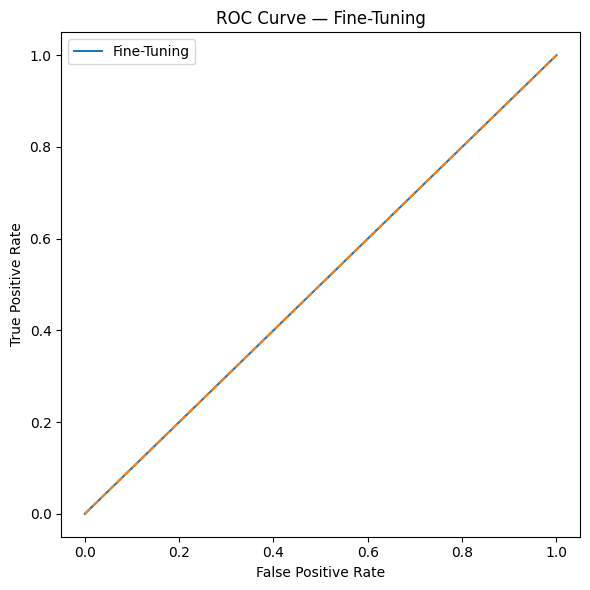

In [6]:
# --- Fine-Tuning baseline ---

fine_tune_model = clone_model_from_stage1(input_dim)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    fine_tune_model.parameters(),
    lr=extract_inner_lr(config, default=1e-3),
    weight_decay=getattr(config, "weight_decay", 1e-4),
)

n_steps = extract_inner_steps(config, default=10)
fine_tune_history = []

fine_tune_model.train()
for step in range(n_steps):
    optimizer.zero_grad()
    logits = fine_tune_model(X_support_t)
    loss = criterion(logits, y_support_t)
    loss.backward()
    optimizer.step()
    fine_tune_history.append({"step": step + 1, "support_loss": float(loss.item())})

fine_tune_probs = predict_proba(fine_tune_model, X_query_t)
fine_tune_metrics = evaluate_on_gold_binary(
    y_true_gold=y_query_np,
    y_pred_prob=fine_tune_probs,
    model_name="FineTuning_Logistics",
)

display(pd.DataFrame(fine_tune_history))
display(fine_tune_metrics)

plot_roc_curve(y_query_np, fine_tune_probs, model_name="Fine-Tuning")
plt.show()


## Block 2: FOMAML Implementation

This block runs a first-order meta-learning approximation.

Conceptually:

- start from the Stage 1 initialization
- adapt on the support set
- evaluate the adapted parameters on the query set
- ignore second-order graph terms

In practice, this gives a lighter-weight alternative to full MAML and is often much easier to stabilize.


,step,support_loss
0,1,0.503496
1,2,0.409477
2,3,0.431438
3,4,0.358103
4,5,0.339542


,model,gold_auroc,gold_ap,gold_logloss,gold_brier,gold_ece,gold_f1,gold_accuracy,gold_pred_mean,gold_true_mean,...,n_positive,precision_at_5,recall_at_5,ndcg_at_5,precision_at_10,recall_at_10,ndcg_at_10,precision_at_20,recall_at_20,ndcg_at_20
0,FOMAML_Logistics,0.79798,0.931232,5.82461,0.708957,0.709276,0.0,0.290323,0.000402,0.709677,...,22,1.0,0.227273,1.0,1.0,0.454545,1.0,0.85,0.772727,0.899474


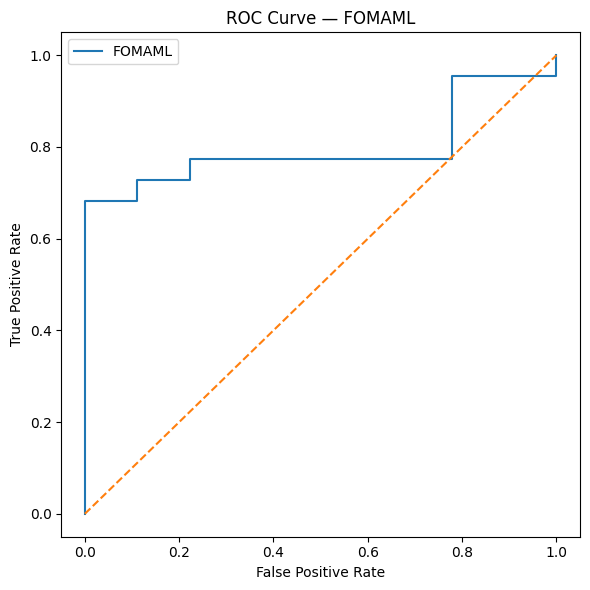

In [7]:
# --- FOMAML ---

def fomaml_adapt(
    model: nn.Module,
    X_support: torch.Tensor,
    y_support: torch.Tensor,
    inner_lr: float,
    inner_steps: int,
):
    adapted = copy.deepcopy(model)
    adapted.train()
    optimizer = torch.optim.SGD(adapted.parameters(), lr=inner_lr)

    criterion = nn.BCEWithLogitsLoss()
    history = []

    for step in range(inner_steps):
        optimizer.zero_grad()
        logits = adapted(X_support)
        loss = criterion(logits, y_support)
        loss.backward()
        optimizer.step()
        history.append({"step": step + 1, "support_loss": float(loss.item())})

    return adapted, pd.DataFrame(history)

fomaml_model = clone_model_from_stage1(input_dim)
fomaml_adapted_model, fomaml_history = fomaml_adapt(
    model=fomaml_model,
    X_support=X_support_t,
    y_support=y_support_t,
    inner_lr=extract_inner_lr(config, default=1e-2),
    inner_steps=extract_inner_steps(config, default=5),
)

fomaml_probs = predict_proba(fomaml_adapted_model, X_query_t)
fomaml_metrics = evaluate_on_gold_binary(
    y_true_gold=y_query_np,
    y_pred_prob=fomaml_probs,
    model_name="FOMAML_Logistics",
)

display(fomaml_history)
display(fomaml_metrics)

plot_roc_curve(y_query_np, fomaml_probs, model_name="FOMAML")
plt.show()


## Block 3: MAML Implementation

This block writes the adaptation logic using explicit `torch.autograd.grad(...)` calls so that inner-loop updates remain differentiable.

Because this notebook focuses on a single held-out Logistics evaluation episode, this block acts as a transparent, notebook-level demonstration of full second-order adaptation rather than a production meta-training loop across many tasks.


,step,support_loss
0,1,0.505020
1,2,0.429206
2,3,0.378963
3,4,0.341573
4,5,0.313533


,model,gold_auroc,gold_ap,gold_logloss,gold_brier,gold_ece,gold_f1,gold_accuracy,gold_pred_mean,gold_true_mean,...,n_positive,precision_at_5,recall_at_5,ndcg_at_5,precision_at_10,recall_at_10,ndcg_at_10,precision_at_20,recall_at_20,ndcg_at_20
0,MAML_Logistics,0.863636,0.95575,0.597457,0.183851,0.207213,0.705882,0.677419,0.550799,0.709677,...,22,1.0,0.227273,1.0,1.0,0.454545,1.0,0.9,0.818182,0.934797


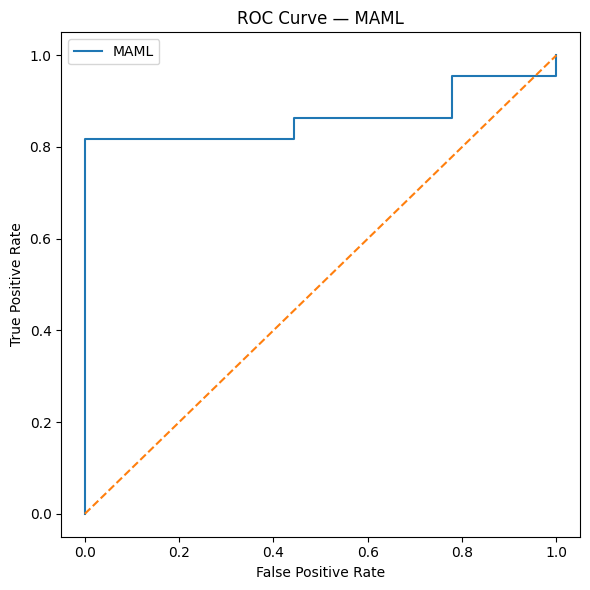

In [8]:
# --- Full MAML-style differentiable adaptation ---

def forward_with_weights(model: nn.Module, x: torch.Tensor, weights: dict[str, torch.Tensor]) -> torch.Tensor:
    # Assumes TabularMLP stores the sequential stack in `model.net`
    h = x
    linear_idx = 0
    batchnorm_idx = 0

    for layer in model.net:
        if isinstance(layer, nn.Linear):
            w = weights[f"linear_{linear_idx}.weight"]
            b = weights[f"linear_{linear_idx}.bias"]
            h = torch.nn.functional.linear(h, w, b)
            linear_idx += 1
        elif isinstance(layer, nn.BatchNorm1d):
            w = weights[f"batchnorm_{batchnorm_idx}.weight"]
            b = weights[f"batchnorm_{batchnorm_idx}.bias"]
            running_mean = torch.zeros_like(w)
            running_var = torch.ones_like(w)
            h = torch.nn.functional.batch_norm(
                h,
                running_mean=running_mean,
                running_var=running_var,
                weight=w,
                bias=b,
                training=True,
            )
            batchnorm_idx += 1
        elif isinstance(layer, nn.ReLU):
            h = torch.relu(h)
        elif isinstance(layer, nn.GELU):
            h = torch.nn.functional.gelu(h)
        elif isinstance(layer, nn.Dropout):
            h = h
        else:
            raise TypeError(f"Unsupported layer in forward_with_weights: {type(layer)}")

    return h

def extract_functional_weights(model: nn.Module) -> dict[str, torch.Tensor]:
    weights = {}
    linear_idx = 0
    batchnorm_idx = 0

    for layer in model.net:
        if isinstance(layer, nn.Linear):
            weights[f"linear_{linear_idx}.weight"] = layer.weight
            weights[f"linear_{linear_idx}.bias"] = layer.bias
            linear_idx += 1
        elif isinstance(layer, nn.BatchNorm1d):
            weights[f"batchnorm_{batchnorm_idx}.weight"] = layer.weight
            weights[f"batchnorm_{batchnorm_idx}.bias"] = layer.bias
            batchnorm_idx += 1

    return weights

def maml_adapt(
    model: nn.Module,
    X_support: torch.Tensor,
    y_support: torch.Tensor,
    inner_lr: float,
    inner_steps: int,
):
    criterion = nn.BCEWithLogitsLoss()
    fast_weights = extract_functional_weights(model)
    history = []

    for step in range(inner_steps):
        logits = forward_with_weights(model, X_support, fast_weights)
        loss = criterion(logits, y_support)
        grads = torch.autograd.grad(
            loss,
            list(fast_weights.values()),
            create_graph=True,
            retain_graph=True,
        )
        fast_weights = {
            name: param - inner_lr * grad
            for (name, param), grad in zip(fast_weights.items(), grads)
        }
        history.append({"step": step + 1, "support_loss": float(loss.item())})

    return fast_weights, pd.DataFrame(history)

maml_model = clone_model_from_stage1(input_dim)
maml_fast_weights, maml_history = maml_adapt(
    model=maml_model,
    X_support=X_support_t,
    y_support=y_support_t,
    inner_lr=extract_inner_lr(config, default=1e-2),
    inner_steps=extract_inner_steps(config, default=5),
)

with torch.no_grad():
    maml_logits_query = forward_with_weights(maml_model, X_query_t, maml_fast_weights)
    maml_probs = torch.sigmoid(maml_logits_query).detach().cpu().numpy().ravel()

maml_metrics = evaluate_on_gold_binary(
    y_true_gold=y_query_np,
    y_pred_prob=maml_probs,
    model_name="MAML_Logistics",
)

display(maml_history)
display(maml_metrics)

plot_roc_curve(y_query_np, maml_probs, model_name="MAML")
plt.show()


## Block 4: ANIL Implementation

ANIL adapts only the **task-specific head** while keeping the feature extractor fixed.

For this notebook, we operationalize that by:

- freezing all layers except the final linear layer
- adapting only the head on the support set
- evaluating on the Logistics query set

This is often more stable than full MAML when support sets are tiny.


,step,support_loss
0,1,0.506501
1,2,0.530777
2,3,0.530119
3,4,0.487511
4,5,0.516471
5,6,0.492864
6,7,0.505962
7,8,0.478179
8,9,0.450646
9,10,0.494750


,model,gold_auroc,gold_ap,gold_logloss,gold_brier,gold_ece,gold_f1,gold_accuracy,gold_pred_mean,gold_true_mean,...,n_positive,precision_at_5,recall_at_5,ndcg_at_5,precision_at_10,recall_at_10,ndcg_at_10,precision_at_20,recall_at_20,ndcg_at_20
0,ANIL_Logistics,0.919192,0.97544,2.035231,0.471675,0.55311,0.307692,0.419355,0.156568,0.709677,...,22,1.0,0.227273,1.0,1.0,0.454545,1.0,1.0,0.909091,1.0


<Figure size 800x600 with 0 Axes>

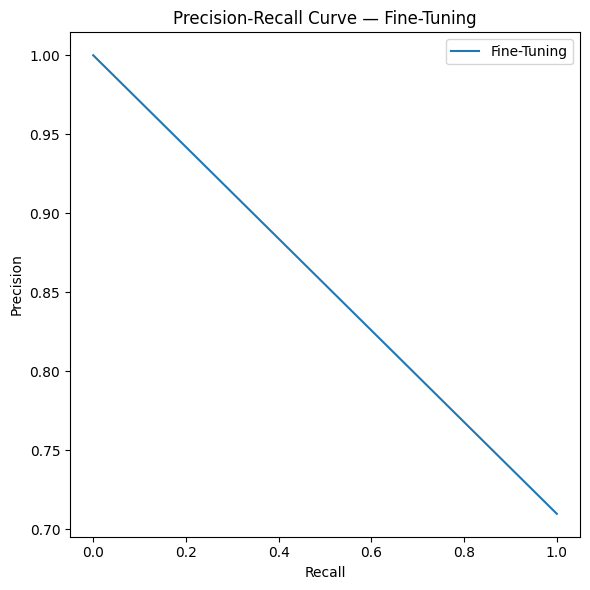

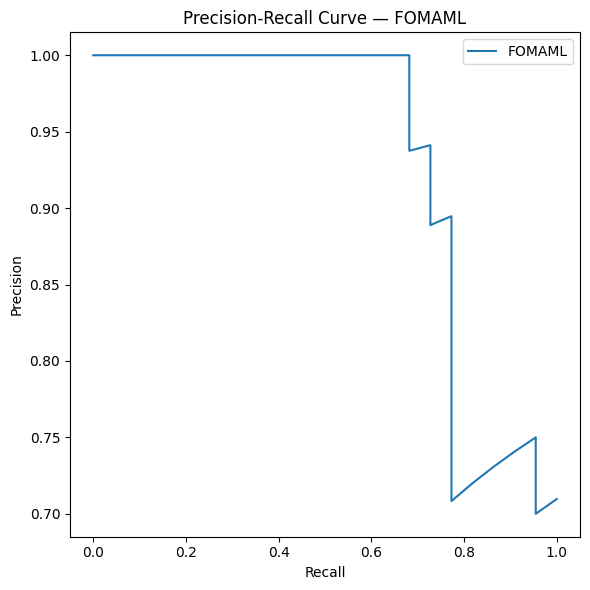

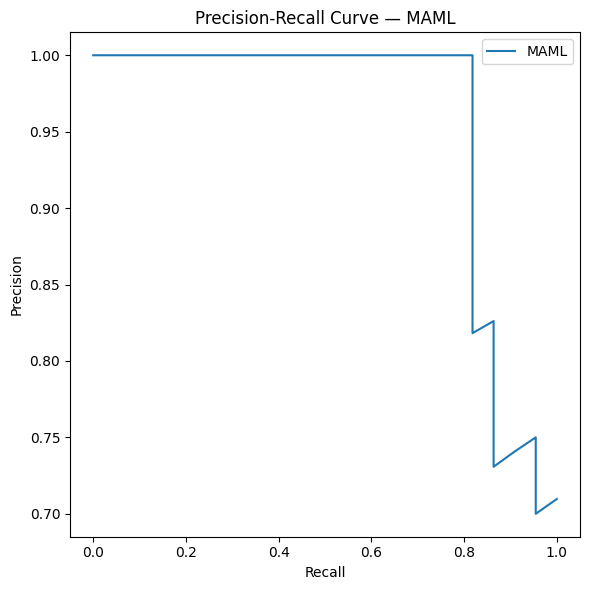

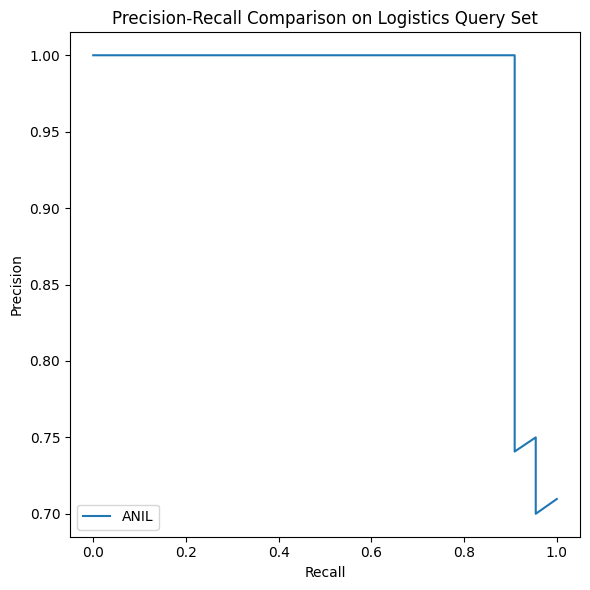

In [9]:
# --- ANIL ---

def freeze_except_last_linear(model: nn.Module):
    linear_layers = [layer for layer in model.net if isinstance(layer, nn.Linear)]
    last_linear = linear_layers[-1]

    for param in model.parameters():
        param.requires_grad = False

    for param in last_linear.parameters():
        param.requires_grad = True

    return model

anil_model = clone_model_from_stage1(input_dim)
anil_model = freeze_except_last_linear(anil_model)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    [p for p in anil_model.parameters() if p.requires_grad],
    lr=extract_inner_lr(config, default=1e-3),
    weight_decay=getattr(config, "weight_decay", 1e-4),
)

anil_history = []
anil_steps = extract_inner_steps(config, default=10)

anil_model.train()
for step in range(anil_steps):
    optimizer.zero_grad()
    logits = anil_model(X_support_t)
    loss = criterion(logits, y_support_t)
    loss.backward()
    optimizer.step()
    anil_history.append({"step": step + 1, "support_loss": float(loss.item())})

anil_probs = predict_proba(anil_model, X_query_t)
anil_metrics = evaluate_on_gold_binary(
    y_true_gold=y_query_np,
    y_pred_prob=anil_probs,
    model_name="ANIL_Logistics",
)

display(pd.DataFrame(anil_history))
display(anil_metrics)

plt.figure(figsize=(8, 6))
plot_precision_recall_curve(y_query_np, fine_tune_probs, model_name="Fine-Tuning")
plot_precision_recall_curve(y_query_np, fomaml_probs, model_name="FOMAML")
plot_precision_recall_curve(y_query_np, maml_probs, model_name="MAML")
plot_precision_recall_curve(y_query_np, anil_probs, model_name="ANIL")
plt.title("Precision-Recall Comparison on Logistics Query Set")
plt.legend()
plt.show()


In [10]:
# --- Final comparison table ---

comparison_df = pd.concat(
    [
        fine_tune_metrics.assign(method="Fine-Tuning"),
        fomaml_metrics.assign(method="FOMAML"),
        maml_metrics.assign(method="MAML"),
        anil_metrics.assign(method="ANIL"),
    ],
    ignore_index=True,
)

priority_cols = [
    "method",
    "gold_auroc",
    "gold_ap",
    "gold_logloss",
    "gold_brier",
    "gold_ece",
    "gold_f1",
    "gold_accuracy",
    "precision_at_10",
    "ndcg_at_10",
]
priority_cols = [c for c in priority_cols if c in comparison_df.columns]

display(comparison_df[priority_cols].sort_values("gold_auroc", ascending=False))


,method,gold_auroc,gold_ap,gold_logloss,gold_brier,gold_ece,gold_f1,gold_accuracy,precision_at_10,ndcg_at_10
3,ANIL,0.919192,0.975440,2.035231,0.471675,0.553110,0.307692,0.419355,1.0,1.000000
2,MAML,0.863636,0.955750,0.597457,0.183851,0.207213,0.705882,0.677419,1.0,1.000000
1,FOMAML,0.797980,0.931232,5.824610,0.708957,0.709276,0.000000,0.290323,1.0,1.000000
0,Fine-Tuning,0.500000,0.709677,5.347940,0.290323,0.290323,0.830189,0.709677,0.7,0.709677
